In [2]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import ffmpeg


In [ ]:
def extract_frames_ffmpeg(video_path, output_dir, quality=2, start_number=0, fps=None, file_pattern='%05d.jpg'):
    """
    Uses ffmpeg-python to extract frames from a video and save as images.

    Args:
        video_path (str): Path to the input video.
        output_dir (str): Directory to save the extracted frames.
        quality (int): Quality level for the output images (lower is better quality).
        start_number (int): Starting number for the output image filenames.
        fps (int/None): The framerate to extract frames at.
        file_pattern (str): Pattern for naming the output images (default: '%05d.jpg').
    
    Returns:
        None
    """
    if os.path.exists(output_dir):
        print(f'{output_dir} exists')
        return
    os.makedirs(output_dir, exist_ok=True)

    # Construct output file path pattern
    output_path = f'{output_dir}/{file_pattern}'

    # Use ffmpeg to extract frames
    stream = ffmpeg.input(video_path)
    if fps is not None:
        stream = stream.filter('fps', fps=fps, round='up')
    stream.output(
        output_path, 
        q=quality,  # Quality for the frames
        start_number=start_number  # Start number for frame file names
    ).run(quiet=True)

In [4]:
extract_frames_ffmpeg("A2_1H_U_04262024171941-0000.avi", 'frames_larger/', fps=5)

frames_larger/ exists


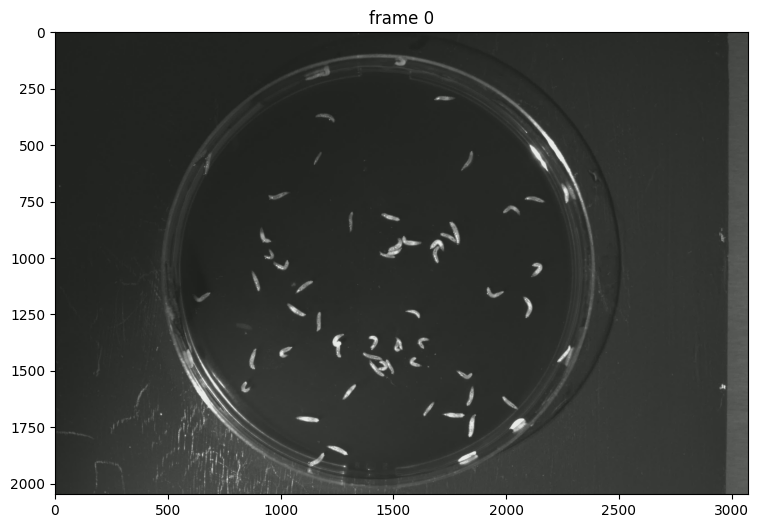

In [8]:
# `video_dir` a directory of JPEG frames with filenames like `<frame_index>.jpg`
video_dir = "frames_larger"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

# take a look the first video frame
frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

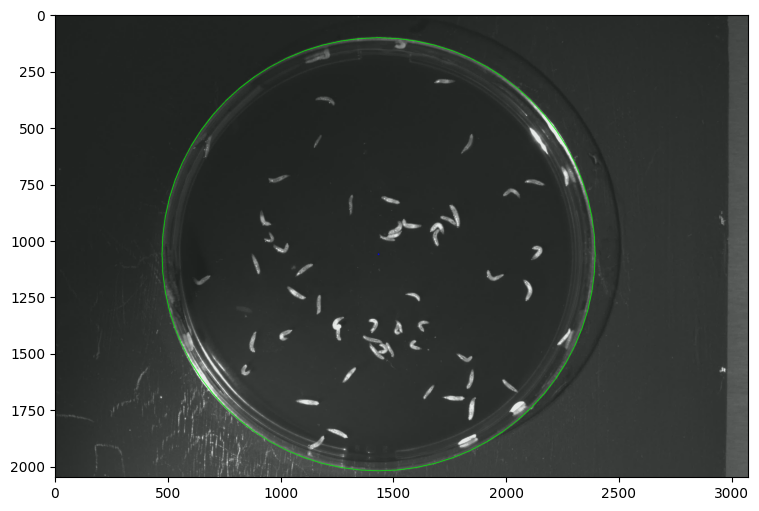

In [ ]:
import cv2
import numpy as np

# Read image
img = cv2.imread("frames_larger/00000.jpg")
output = img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray = cv2.medianBlur(gray, 5)

# Detect circles
circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=100,      
    param1=100,         
    param2=40,       
    minRadius=800,       
    maxRadius=15000
)

# Draw only the first detected circle
if circles is not None:
    circles = np.uint16(np.around(circles))
    x, y, r = circles[0][0]
    cv2.circle(output, (x, y), r, (0, 255, 0), 2)  # Circle outline
    cv2.circle(output, (x, y), 2, (0, 0, 255), 3)  # Center point

# Show result
plt.figure(figsize=(9, 6))
plt.imshow(output)

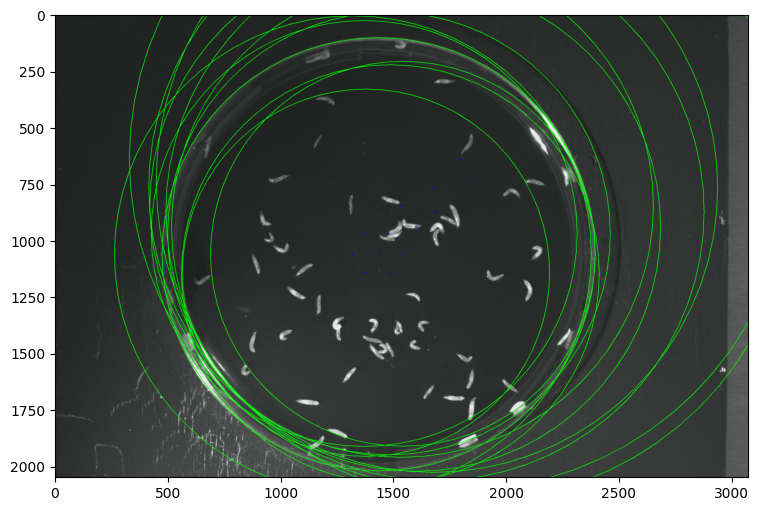

In [10]:
for circle in circles[0]:
    x, y, r = circle
    cv2.circle(output, (x, y), r, (0, 255, 0), 2)  # Circle outline
    cv2.circle(output, (x, y), 2, (0, 0, 255), 3)  # Center point

# Show result
plt.figure(figsize=(9, 6))
plt.imshow(output)

Outer circle: center=(1434,1060), radius=960
Inner circle: center=(1350,1150), radius=792


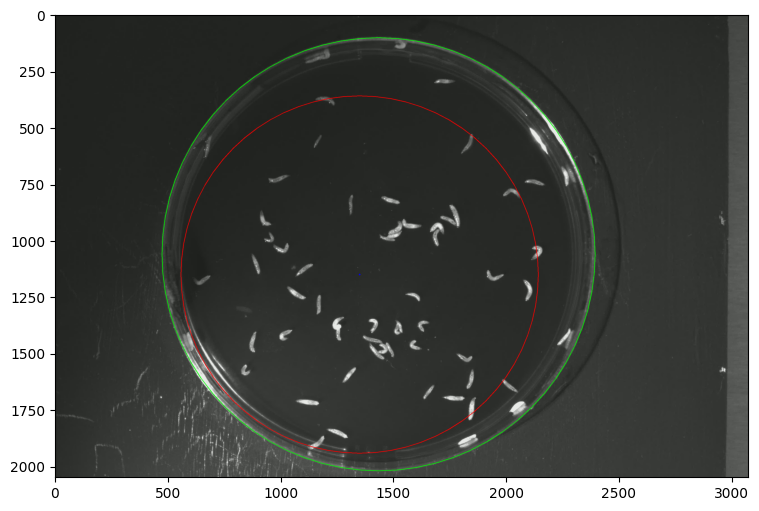

In [15]:
img = cv2.imread("frames_larger/00000.jpg")
output = img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray, 5)

# --- Step 1: Detect the OUTER circle (your existing code) ---
outer_circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=100,
    param1=100,
    param2=40,
    minRadius=800,
    maxRadius=15000
)

# --- Step 2: Detect the INNER circle (smaller radius range) ---
inner_circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=100,
    param1=100,
    param2=30,          # slightly more lenient
    minRadius=400,      # smaller than outer
    maxRadius=800       # upper bound < outer minRadius
)

# Draw outer circle (green)
if outer_circles is not None:
    outer_circles = np.uint16(np.around(outer_circles))
    x, y, r = outer_circles[0][0]
    cv2.circle(output, (x, y), r, (0, 255, 0), 2)
    print(f"Outer circle: center=({x},{y}), radius={r}")

# Draw inner circle (red)
if inner_circles is not None:
    inner_circles = np.uint16(np.around(inner_circles))
    x, y, r = inner_circles[0][0]
    cv2.circle(output, (x, y), r, (0, 0, 255), 2)
    cv2.circle(output, (x, y), 2, (255, 0, 0), 3)
    print(f"Inner circle: center=({x},{y}), radius={r}")

plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.show()

Inner circle: center=(1434,1060), radius=863


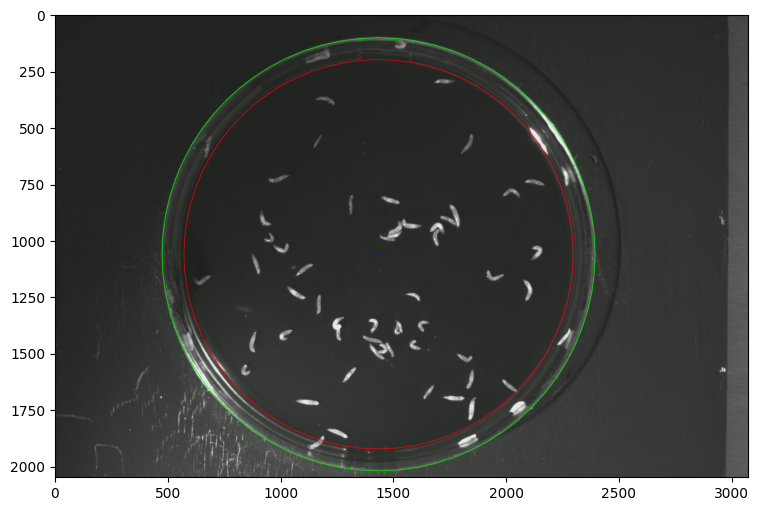

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("frames_larger/00000.jpg")
output = img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray, 5)

# --- Step 1: Find outer circle ---
outer_circles = cv2.HoughCircles(
    gray, cv2.HOUGH_GRADIENT,
    dp=1, minDist=100,
    param1=100, param2=40,
    minRadius=800, maxRadius=15000
)

if outer_circles is not None:
    outer_circles = np.uint16(np.around(outer_circles))
    ox, oy, outer_r = outer_circles[0][0]

    # --- Step 2: Create a mask for the region INSIDE the outer circle ---
    mask = np.zeros_like(gray)
    cv2.circle(mask, (ox, oy), int(outer_r * 0.9), 255, -1)  # shrink slightly
    
    # Apply mask to gray image
    masked_gray = cv2.bitwise_and(gray, gray, mask=mask)

    # --- Step 3: Enhance edges inside the cup ---
    # CLAHE improves contrast of the inner surface edge
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    masked_gray = clahe.apply(masked_gray)
    masked_gray = cv2.medianBlur(masked_gray, 5)

    # --- Step 4: Detect inner circle ---
    inner_circles = cv2.HoughCircles(
        masked_gray, cv2.HOUGH_GRADIENT,
        dp=1, minDist=50,
        param1=80,
        param2=30,
        minRadius=int(outer_r * 0.3),   # inner is typically 30-90% of outer
        maxRadius=int(outer_r * 0.9)
    )

    # Draw outer (green)
    cv2.circle(output, (ox, oy), outer_r, (0, 255, 0), 2)

    # Draw inner (red)
    if inner_circles is not None:
        inner_circles = np.uint16(np.around(inner_circles))
        ix, iy, ir = inner_circles[0][0]
        cv2.circle(output, (ix, iy), ir, (0, 0, 255), 2)
        cv2.circle(output, (ix, iy), 2, (255, 0, 0), 3)
        print(f"Inner circle: center=({ix},{iy}), radius={ir}")

plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.show()

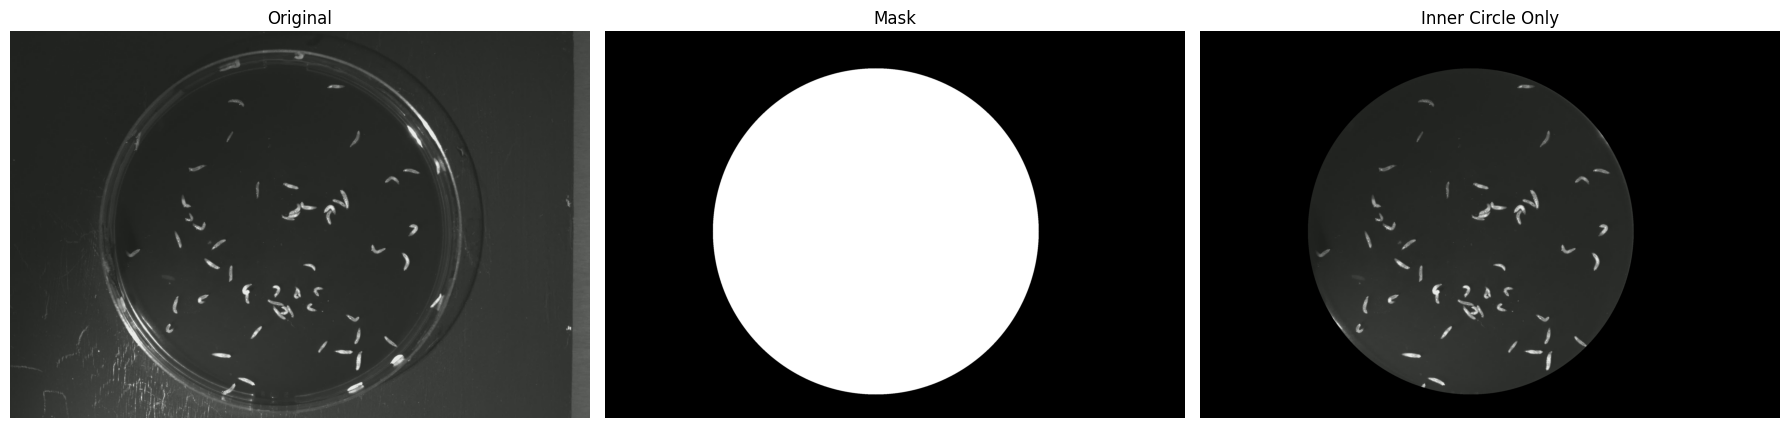

In [17]:
        # Create a black mask
        final_mask = np.zeros_like(gray)
        
        # Fill inner circle with white
        cv2.circle(final_mask, (ix, iy), ir, 255, -1)
        
        # Apply mask to original image (black outside)
        result = cv2.bitwise_and(img, img, mask=final_mask)

        # --- Display ---
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Original")
        
        axes[1].imshow(final_mask, cmap='gray')
        axes[1].set_title("Mask")
        
        axes[2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
        axes[2].set_title("Inner Circle Only")
        
        for ax in axes:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

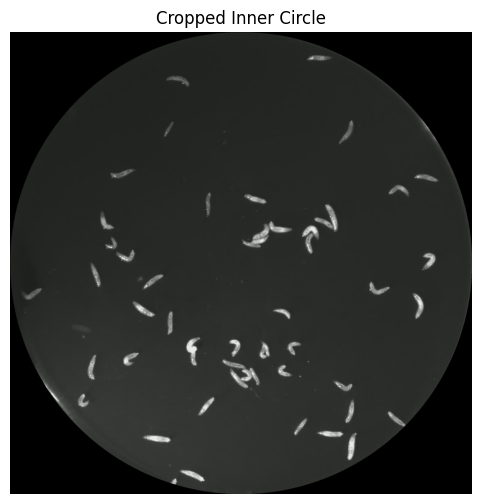

In [18]:
        # Crop to bounding box of inner circle
        x1 = max(ix - ir, 0)
        y1 = max(iy - ir, 0)
        x2 = min(ix + ir, img.shape[1])
        y2 = min(iy + ir, img.shape[0])

        cropped = result[y1:y2, x1:x2]

        plt.figure(figsize=(6, 6))
        plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
        plt.title("Cropped Inner Circle")
        plt.axis('off')
        plt.show()

Found 267 frames

✓ Inner circle detected: center=(1434, 1060), radius=863


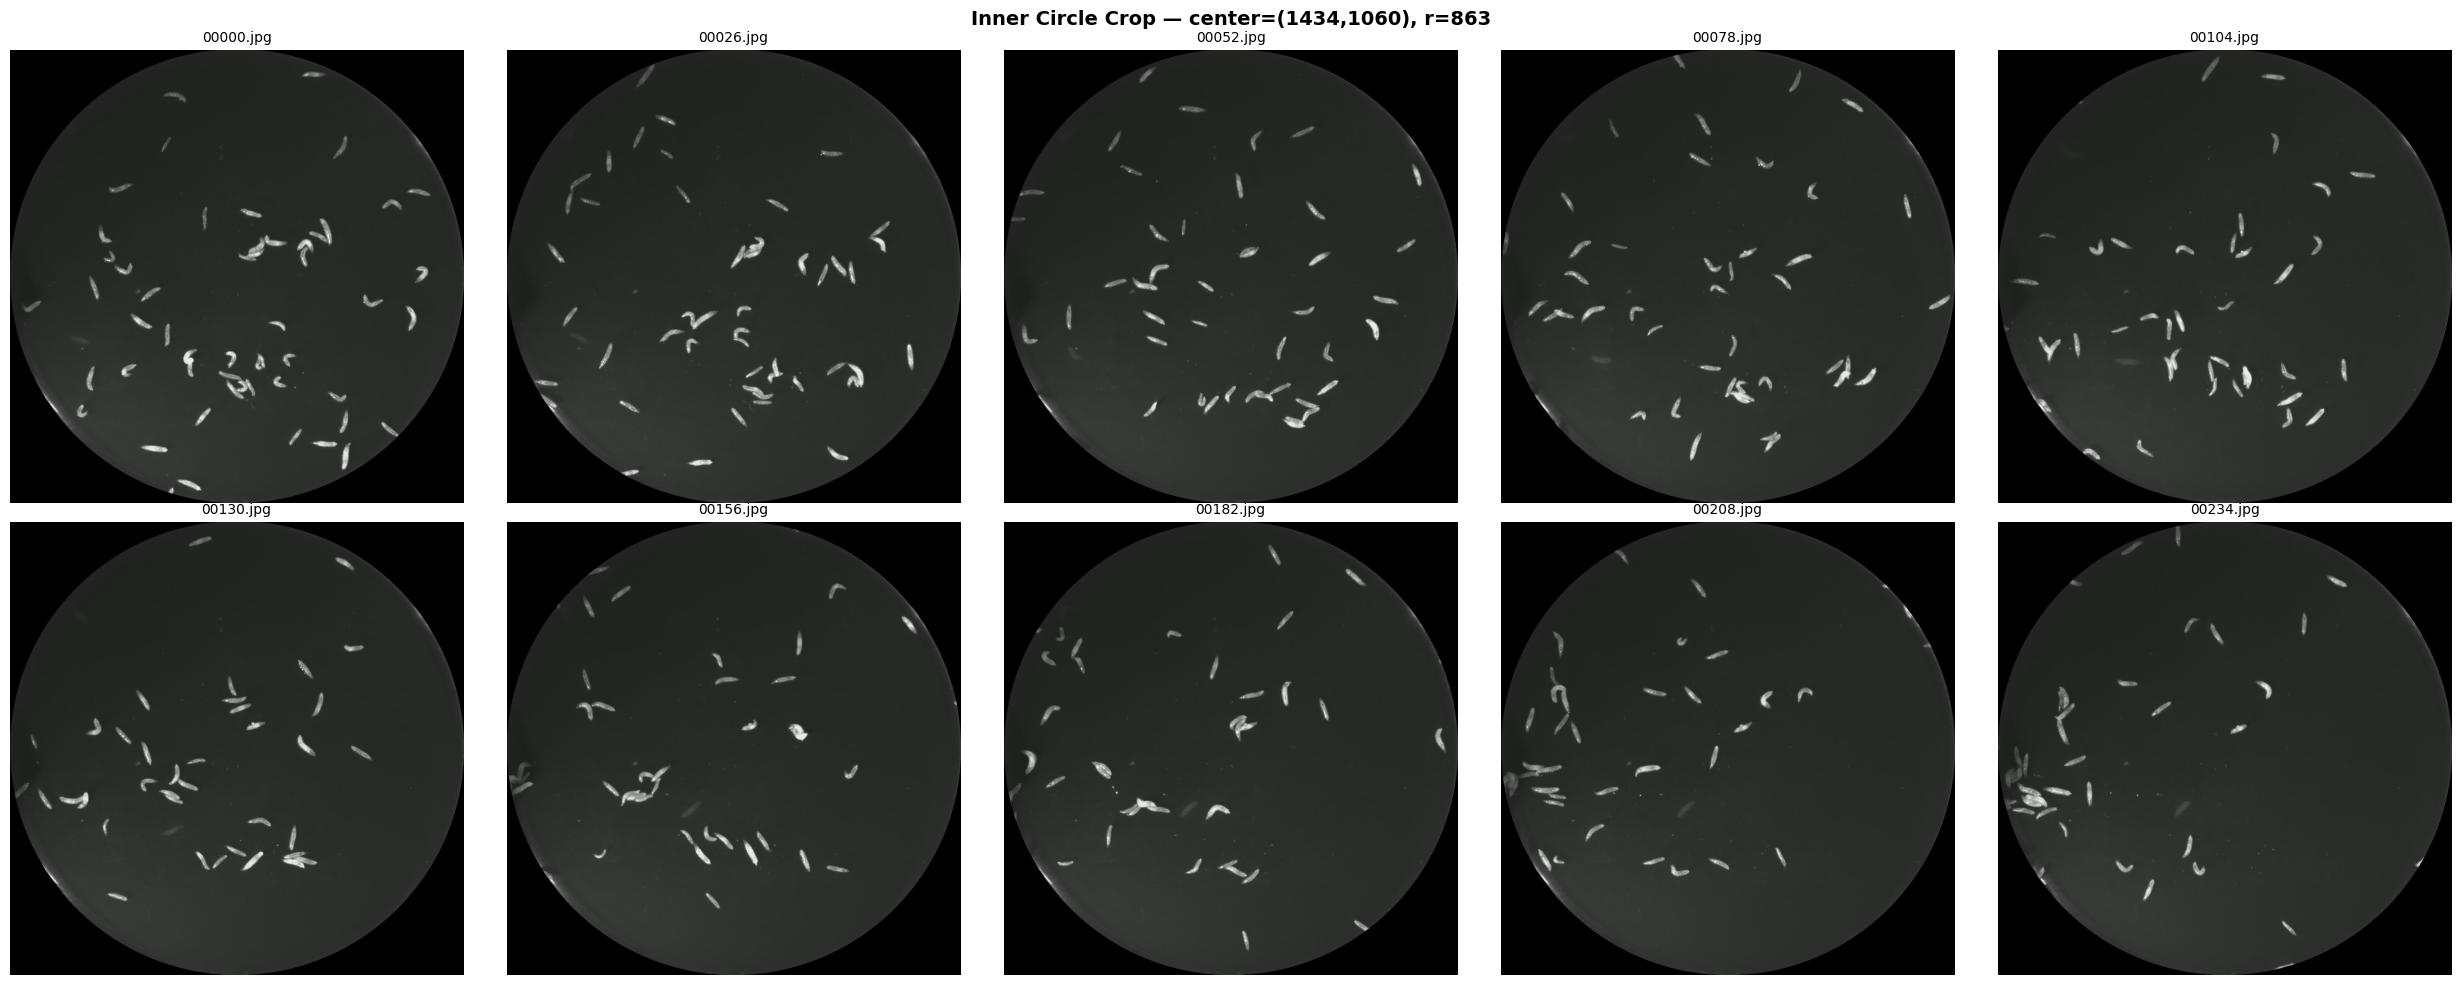

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

def detect_inner_circle(img_path):
    """Detect inner circle from a single reference frame."""
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.medianBlur(gray, 5)

    # Find outer circle
    outer_circles = cv2.HoughCircles(
        gray, cv2.HOUGH_GRADIENT,
        dp=1, minDist=100,
        param1=100, param2=40,
        minRadius=800, maxRadius=15000
    )
    
    if outer_circles is None:
        raise ValueError("No outer circle found!")

    outer_circles = np.uint16(np.around(outer_circles))
    ox, oy, outer_r = outer_circles[0][0]

    # Find inner circle
    mask_search = np.zeros_like(gray)
    cv2.circle(mask_search, (ox, oy), int(outer_r * 0.9), 255, -1)
    masked_gray = cv2.bitwise_and(gray, gray, mask=mask_search)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    masked_gray = clahe.apply(masked_gray)
    masked_gray = cv2.medianBlur(masked_gray, 5)

    inner_circles = cv2.HoughCircles(
        masked_gray, cv2.HOUGH_GRADIENT,
        dp=1, minDist=50,
        param1=80, param2=30,
        minRadius=int(outer_r * 0.3),
        maxRadius=int(outer_r * 0.9)
    )

    if inner_circles is None:
        raise ValueError("No inner circle found!")

    inner_circles = np.uint16(np.around(inner_circles))
    ix, iy, ir = inner_circles[0][0]

    print(f"✓ Inner circle detected: center=({ix}, {iy}), radius={ir}")
    return int(ix), int(iy), int(ir)


def crop_with_circle(img_path, cx, cy, r):
    """Apply pre-detected circle mask and crop."""
    img = cv2.imread(img_path)
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    cv2.circle(mask, (cx, cy), r, 255, -1)
    result = cv2.bitwise_and(img, img, mask=mask)

    # Crop to bounding box
    x1 = max(cx - r, 0)
    y1 = max(cy - r, 0)
    x2 = min(cx + r, img.shape[1])
    y2 = min(cy + r, img.shape[0])
    return result[y1:y2, x1:x2]


# --- Step 1: Get all frames ---
all_images = sorted(glob.glob("frames_larger/*.jpg"))
print(f"Found {len(all_images)} frames\n")

# --- Step 2: Detect circle ONCE from first frame ---
cx, cy, r = detect_inner_circle(all_images[0])

# --- Step 3: Apply to 10 evenly spaced frames ---
step = max(len(all_images) // 10, 1)
selected = all_images[::step][:10]

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for i, img_path in enumerate(selected):
    cropped = crop_with_circle(img_path, cx, cy, r)
    axes[i].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
    axes[i].set_title(os.path.basename(img_path), fontsize=10)
    axes[i].axis('off')

plt.suptitle(f"Inner Circle Crop — center=({cx},{cy}), r={r}", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# --- Get all frames ---
all_images = sorted(glob.glob("frames_larger/*.jpg"))
print(f"Found {len(all_images)} frames")

# --- Detect circle ONCE ---
cx, cy, r = detect_inner_circle(all_images[0])
print(f"✓ Circle detected: center=({cx}, {cy}), radius={r}\n")

# --- Crop and save ALL ---
output_dir = "frames_cropped"
os.makedirs(output_dir, exist_ok=True)

for i, img_path in enumerate(all_images):
    cropped = crop_with_circle(img_path, cx, cy, r)
    filename = os.path.basename(img_path)
    cv2.imwrite(os.path.join(output_dir, filename), cropped)
    
    # Progress update every 50 frames
    if (i + 1) % 50 == 0 or (i + 1) == len(all_images):
        print(f"  Saved {i + 1}/{len(all_images)}")

print(f"\n✓ Done! All {len(all_images)} cropped frames saved to '{output_dir}/'")

Found 267 frames
✓ Inner circle detected: center=(1434, 1060), radius=863
✓ Circle detected: center=(1434, 1060), radius=863

  Saved 50/267
  Saved 100/267
  Saved 150/267
  Saved 200/267
  Saved 250/267
  Saved 267/267

✓ Done! All 267 cropped frames saved to 'frames_cropped/'
